# Parse Rhea
__Parsing Rhea data into a network for LipiNet.__

LipiNet offers conventient functions to parse prior knowledge resources straight into networks. For instance, LipiNet can parse Rhea data into a network as easily as running: `parse_rhea_data()`

However to show what is happening behind the scenes, this notebook will also go through the data and each of the steps that are made in the background of this function. This may be particularly helpful for users needing to customise the networks in a way that is not yet supported by LipiNet directly. 

## Using `parse_rhea_data()`

The LipiNet `parse_rhea_data()` function automatically parses Rhea data into a network. This is what LipiNet uses as input to its overall combined network and for the majority of users this function will probably suffice if they wish to build sub-networks with just Rhea data.

In [ ]:
from lipinet.parse_rhea import parse_rhea_data

rhea_results = parse_rhea_data(verbose=False, use_cache=True)
df_rhea_nodes = rhea_results['df_nodes']
df_rhea_edges = rhea_results['df_edges']

To avoid repeatedly downloading the Rhea data (and choking up their server calls), set `use_cache=True`. If the cache has not been set yet, this will automatically save the download to cache. If there is already a cache, it will use that.

To override the cache you can set `force_download=True`, but this is only recommended every few months when you want to update the source data in case of changes.

### Where to from here?

- Now to quickly start exploring Rhea, go to the [Explore Rhea notebook](explore_rhea.ipynb).
- To see how the combined LipiNet network uses Rhea, go to the [Explore LipiNet notebook](explore_lipinet.ipynb).
- Or to see how the `parse_rhea_data()` function works behind the scenes, continue to the [Manual parsing](#manual-parsing) section below.

## Manual parsing

For users wanting to better understand all the steps being undertaken behind the `parse_rhea_data()` function, we will recreate the steps here.

In [1]:
import importlib

# Reload the module to ensure changes are picked up
#importlib.reload(lipinet)

# Now can use the functions after reloading the module
from lipinet.databases import get_prior_knowledge 
from lipinet.utils import split_and_expand_large, create_nodedf_from_edgedf, check_for_split_characters

import pandas as pd

In [2]:
import plotly.express as px
import seaborn as sns 
import missingno as msno 
import matplotlib.pyplot as plt

In [3]:
# Use the get_prior_knowledge function for df_rhea
df_rhea = get_prior_knowledge('rhea', verbose=True)
df_rhea

File found locally at /Users/agjanyunlu/Documents/Metabolomics/lipinet/lipinet/.data/downloaded/rhea.tsv. Loading data...


,Reaction identifier,Equation,ChEBI name,ChEBI identifier,EC number,Enzymes,Gene Ontology,PubMed,Cross-reference (EcoCyc),Cross-reference (MetaCyc),Cross-reference (KEGG),Cross-reference (Reactome),Cross-reference (M-CSA)
0,RHEA:21252,(S)-2-hydroxyglutarate + A = 2-oxoglutarate + AH2,(S)-2-hydroxyglutarate;A;2-oxoglutarate;AH2,CHEBI:16782;CHEBI:13193;CHEBI:16810;CHEBI:17499,EC:1.1.99.2,4258,GO:0047545 2-hydroxyglutarate dehydrogenase ac...,16746551;16005139;34555022;19586914,NaN,MetaCyc:2-HYDROXYGLUTARATE-DEHYDROGENASE-RXN,KEGG:R00298,NaN,NaN
1,RHEA:21256,3-phosphoshikimate + phosphoenolpyruvate = 5-O...,3-phosphoshikimate;phosphoenolpyruvate;5-O-(1-...,CHEBI:145989;CHEBI:58702;CHEBI:57701;CHEBI:43474,EC:2.5.1.19,44340,GO:0003866 3-phosphoshikimate 1-carboxyvinyltr...,4289188;1344882;11300775,EcoCyc:2.5.1.19-RXN,MetaCyc:2.5.1.19-RXN,KEGG:R03460,NaN,NaN
2,RHEA:21260,[thioredoxin]-disulfide + L-methionine + H2O =...,L-cystine residue;L-methionine;H2O;L-methionin...,CHEBI:50058;CHEBI:57844;CHEBI:15377;CHEBI:5877...,EC:1.8.4.14,3112,GO:0033745 L-methionine-(R)-S-oxide reductase ...,20382110;20504774;20851894;19049972;12504094;2...,EcoCyc:1.8.4.14-RXN,MetaCyc:1.8.4.14-RXN,KEGG:R07608,NaN,NaN
3,RHEA:21264,glycolate + A = glyoxylate + AH2,glycolate;A;glyoxylate;AH2,CHEBI:29805;CHEBI:13193;CHEBI:36655;CHEBI:17499,EC:1.1.99.14,14321,GO:0019154 glycolate dehydrogenase activity,4557653,EcoCyc:GLYCOLATEDEHYDRO-RXN,MetaCyc:GLYCOLATEDEHYDRO-RXN,KEGG:R00476,NaN,NaN
4,RHEA:21268,(R)-canadine + 2 NADP(+) = berberine + 2 NADPH...,(R)-canadine;NADP(+);berberine;NADPH;H(+),CHEBI:18146;CHEBI:58349;CHEBI:16118;CHEBI:5778...,EC:1.5.1.31,0,GO:0050623 berberine reductase activity,NaN,NaN,MetaCyc:1.5.1.31-RXN,KEGG:R07169,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17778,RHEA:21232,L-histidine = trans-urocanate + NH4(+),L-histidine;trans-urocanate;NH4(+),CHEBI:57595;CHEBI:17771;CHEBI:28938,EC:4.3.1.3,21113,GO:0004397 histidine ammonia-lyase activity,15906398;11732994;39337646,NaN,MetaCyc:HISTIDINE-AMMONIA-LYASE-RXN,KEGG:R01168,Reactome:R-HSA-70899.6,NaN
17779,RHEA:21236,"anthranilate + NADPH + O2 + 2 H(+) = 2,3-dihyd...","anthranilate;NADPH;O2;H(+);2,3-dihydroxybenzoa...",CHEBI:16567;CHEBI:57783;CHEBI:15379;CHEBI:1537...,EC:1.14.13.35,0,GO:0018672 anthranilate 3-monooxygenase (deami...,6501219;3793735,NaN,MetaCyc:1.14.13.35-RXN,KEGG:R00980,NaN,NaN
17780,RHEA:21240,geranylgeranyl diphosphate + L-cysteinyl-[prot...,geranylgeranyl diphosphate;L-cysteine residue;...,CHEBI:57533;CHEBI:29950;CHEBI:86021;CHEBI:33019,EC:2.5.1.59;EC:2.5.1.60,10991,GO:0004661 protein geranylgeranyltransferase a...,12036349;9121446;19894725;8106351;10745007;126...,NaN,MetaCyc:RXN-3701,NaN,NaN,NaN
17781,RHEA:21244,an 8-hydroxyfurocoumarin + S-adenosyl-L-methio...,an 8-hydroxyfurocoumarin;S-adenosyl-L-methioni...,CHEBI:52025;CHEBI:59789;CHEBI:52028;CHEBI:5785...,EC:2.1.1.70,0,NaN,156999;15009205;28084,NaN,MetaCyc:2.1.1.70-RXN,KEGG:R02982,NaN,NaN


<Axes: >

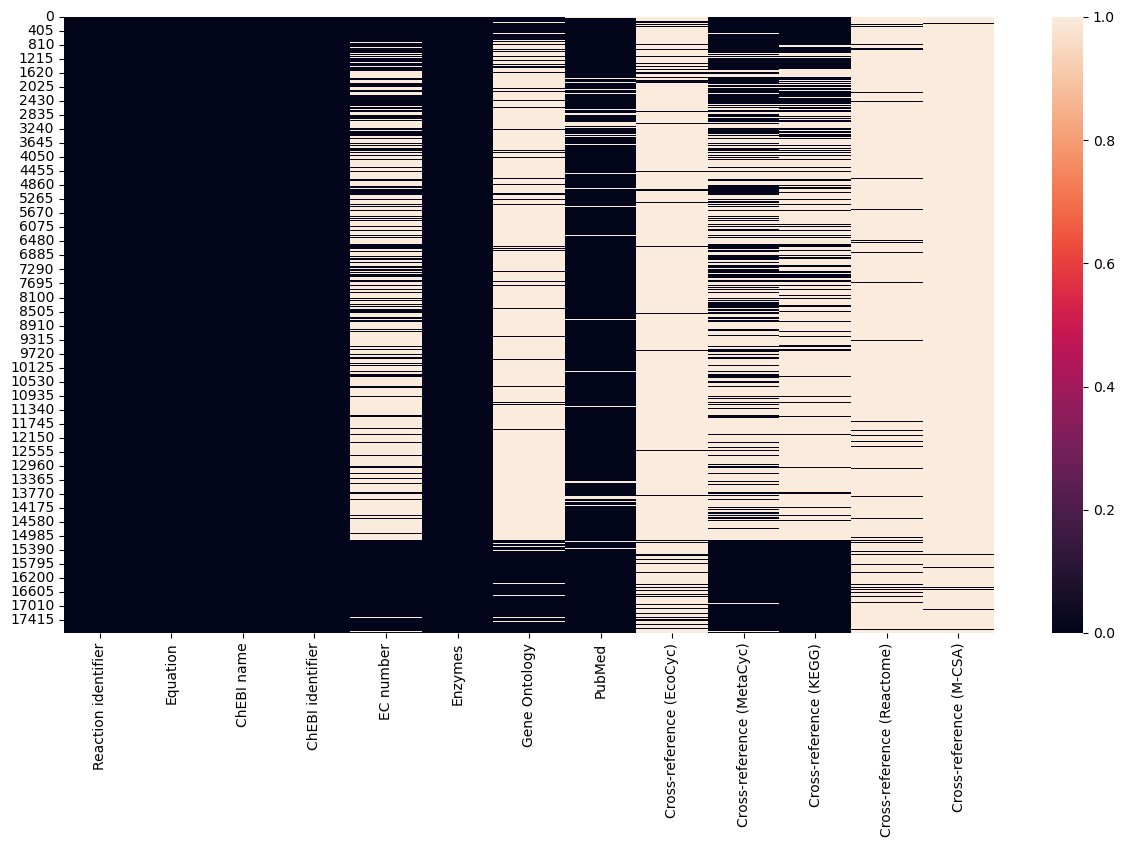

In [4]:
# Create a figure with a specific size
fig, ax = plt.subplots(figsize=(15, 8))  # Adjust the figsize parameter (width, height)

# Create the heatmap
sns.heatmap(df_rhea.isnull(), ax=ax) #sns.heatmap(df, ax=ax, cmap="YlGnBu")

What is the most common participant identifier across all entries?

In [5]:
df_rhea['ChEBI identifier'].str.split(';').explode().value_counts()

ChEBI identifier
CHEBI:15378     9932
CHEBI:15377     6485
CHEBI:15379     2851
CHEBI:57287     1567
CHEBI:58349     1335
                ... 
CHEBI:138211       1
CHEBI:138191       1
CHEBI:18534        1
CHEBI:18533        1
CHEBI:52028        1
Name: count, Length: 13723, dtype: int64

What are the names of these molecules?

In [6]:
df_rhea['ChEBI name'].str.split(';').explode().value_counts()

ChEBI name
H(+)                                                      9932
H2O                                                       6485
O2                                                        2851
CoA                                                       1567
NADP(+)                                                   1335
                                                          ... 
1-octadecanoyl-2-pentanoyl-sn-glycero-3-phosphocholine       1
3'-(N-acyl-L-alpha-aminoacyl)adenylyl 3'-end residue         1
campest-4-en-3-one                                           1
5alpha-campestan-3-one                                       1
an 8-methoxyfurocoumarin                                     1
Name: count, Length: 13723, dtype: int64

So it seems that Hydrogen ions, water, and O2 are the most common ChEBI molecules in Rhea

Are there any commonly represented GO terms?

In [7]:
df_rhea['Gene Ontology'].value_counts(dropna=False)

Gene Ontology
NaN                                                                                            13398
GO:0047545 2-hydroxyglutarate dehydrogenase activity                                               1
GO:0015046 rubredoxin-NADP+ reductase activity                                                     1
GO:0004413 homoserine kinase activity                                                              1
GO:0008721 D-serine ammonia-lyase activity                                                         1
                                                                                               ...  
GO:0008176 tRNA (guanine(46)-N7)-methyltransferase activity                                        1
GO:0030697 tRNA (uracil(54)-C5)-methyltransferase activity, S-adenosyl methionine-dependent        1
GO:0043828 tRNA 2-selenouridine synthase activity                                                  1
GO:0052914 16S rRNA (guanine(1207)-N(2))-methyltransferase activity          

It seems that all GO terms are unique, besides the ones that are NaN.

What about common enzyme classes?

In [8]:
# df_rhea['Enzyme class'].value_counts()

How many don't have any ec class?

In [9]:
df_rhea['EC number'].notna().value_counts()

EC number
False    10214
True      7569
Name: count, dtype: int64

What about EC number, taking into account the possibility for multiple enzyme class numbers to be assigned per reaction?

In [10]:
df_rhea['EC number'].str.split(';').explode().value_counts()

EC number
EC:3.6.1.9        14
EC:1.14.13.105    13
EC:1.14.12.23     12
EC:2.7.4.6        12
EC:3.1.3.62       12
                  ..
EC:2.5.1.122       1
EC:2.5.1.121       1
EC:2.4.1.328       1
EC:2.4.1.326       1
EC:2.7.7.48        1
Name: count, Length: 6153, dtype: int64

How common is it actually to have multiple EC numbers?

In [11]:
df_rhea['EC number'].str.split(';').str.len().value_counts()

EC number
1.0     7343
2.0      202
3.0       18
17.0       2
7.0        2
5.0        1
4.0        1
Name: count, dtype: int64

Note that the IUBMB number actually is determined by a hierarchy. Because of this, let's turn it into a nice df ready to be parsed as a hierarchy.

#### Preparing the Rhea enzyme classification (EC) info

In [12]:
def process_ec_numbers(df):
    """
    Process the 'EC number' column of the input DataFrame.

    Parameters:
        df (pd.DataFrame): A DataFrame containing an 'EC number' column.

    Returns:
        pd.DataFrame: A new DataFrame with the following columns:
            - 'EC_number': The reassembled EC number in the format 'EC:Main_Class.Subclass.Subsubclass.Serial_Number'
            - 'Main_Class': The first part of the EC number.
            - 'Subclass': The second part of the EC number.
            - 'Subsubclass': The third part of the EC number.
            - 'Serial_Number': The fourth part of the EC number.
    """
    # Split, explode, deduplicate, clean and split by '.' into a Series of lists.
    ec_num_series = df['EC number'].str.split(';')\
                        .explode()\
                        .drop_duplicates()\
                        .dropna()\
                        .str.strip('EC:')\
                        .str.split('.')
    
    # Convert the Series of lists into a DataFrame with named columns.
    df_ec = pd.DataFrame(ec_num_series.tolist(), 
                         columns=["Main_Class", "Subclass", "Subsubclass", "Serial_Number"])
    
    # Create a new column with the reassembled EC number in the original format.
    df_ec.insert(0, 'EC_number', 
                 'EC:' + df_ec["Main_Class"].astype(str) + '.' +
                 df_ec["Subclass"].astype(str) + '.' +
                 df_ec["Subsubclass"].astype(str) + '.' +
                 df_ec["Serial_Number"].astype(str))
    
    return df_ec

In [13]:
# Assuming df_rhea is your original DataFrame with the 'EC number' column.
df_ec = process_ec_numbers(df_rhea)
df_ec

,EC_number,Main_Class,Subclass,Subsubclass,Serial_Number
0,EC:1.1.99.2,1,1,99,2
1,EC:2.5.1.19,2,5,1,19
2,EC:1.8.4.14,1,8,4,14
3,EC:1.1.99.14,1,1,99,14
4,EC:1.5.1.31,1,5,1,31
...,...,...,...,...,...
6148,EC:1.14.13.35,1,14,13,35
6149,EC:2.5.1.59,2,5,1,59
6150,EC:2.5.1.60,2,5,1,60
6151,EC:2.7.7.6,2,7,7,6


In [14]:
def build_rhea_ec_edges_and_nodes(df_ec: pd.DataFrame):
    """
    Given a DataFrame with EC hierarchy columns:
        Main_Class, Subclass, Subsubclass, EC_number,
    this function creates:
      - A DataFrame of edges linking each hierarchical level.
      - A DataFrame of unique nodes with a 'ec_level' column 
        indicating the node's level in the hierarchy.
    """

    # -- Make a copy so we don't modify the original df in-place
    df = df_ec.copy()

    # 1) Build the node representations for each hierarchy level
    #    (convert to string just in case they're numeric)
    df["main_node"] = "EC:" + df["Main_Class"].astype(str)
    df["subclass_node"] = (
        "EC:" + df["Main_Class"].astype(str) 
        + "." + df["Subclass"].astype(str)
    )
    df["subsubclass_node"] = (
        "EC:" + df["Main_Class"].astype(str) 
        + "." + df["Subclass"].astype(str)
        + "." + df["Subsubclass"].astype(str)
    )

    # 2) Create edges for each hierarchical link and label them
    edges1 = df[["main_node", "subclass_node"]].rename(
        columns={"main_node": "source_id", "subclass_node": "target_id"}
    )
    edges1["ec_level"] = "main_class->subclass"

    edges2 = df[["subclass_node", "subsubclass_node"]].rename(
        columns={"subclass_node": "source_id", "subsubclass_node": "target_id"}
    )
    edges2["ec_level"] = "subclass->subsubclass"

    edges3 = df[["subsubclass_node", "EC_number"]].rename(
        columns={"subsubclass_node": "source_id", "EC_number": "target_id"}
    )
    edges3["ec_level"] = "subsubclass->EC_number"

    # Concatenate edges and drop duplicates
    edges_df = pd.concat([edges1, edges2, edges3], ignore_index=True).drop_duplicates()

    # Add the additional columns for your graph structure
    edges_df["source_layer"] = "rhea_ec"
    edges_df["target_layer"] = "rhea_ec"
    edges_df["interlayer"] = False

    # 3) Build a node DataFrame from all unique source/target IDs
    nodes_df = pd.DataFrame(
        pd.concat([edges_df["source_id"], edges_df["target_id"]]).unique(),
        columns=["node_id"]
    )
    nodes_df["layer"] = "rhea_ec"  # same layer for all

    # 4) Build a small lookup table to label each node with ec_level
    #    We'll mark each node as either "main_class", "subclass", "subsubclass", or "full_ec".
    df_main = (
        df[["main_node"]].drop_duplicates().rename(columns={"main_node": "node_id"})
    )
    df_main["ec_level"] = "main_class"

    df_sub = (
        df[["subclass_node"]].drop_duplicates().rename(columns={"subclass_node": "node_id"})
    )
    df_sub["ec_level"] = "subclass"

    df_subsub = (
        df[["subsubclass_node"]].drop_duplicates().rename(columns={"subsubclass_node": "node_id"})
    )
    df_subsub["ec_level"] = "subsubclass"

    df_full = (
        df[["EC_number"]].drop_duplicates().rename(columns={"EC_number": "node_id"})
    )
    df_full["ec_level"] = "full_ec"

    df_nodes_level = pd.concat([df_main, df_sub, df_subsub, df_full], ignore_index=True)
    df_nodes_level.drop_duplicates(subset="node_id", inplace=True)

    # 5) Merge the node-level info into the nodes_df
    nodes_df = nodes_df.merge(df_nodes_level, on="node_id", how="left")

    # Return the final DataFrames
    return edges_df, nodes_df

# Example usage:
# df_edges_rhea_ec, df_nodes_rhea_ec = build_rhea_ec_edges_and_nodes(df_ec)

In [15]:
df_edges_rhea_ec, df_nodes_rhea_ec = build_rhea_ec_edges_and_nodes(df_ec)

In [16]:
df_edges_rhea_ec

,source_id,target_id,ec_level,source_layer,target_layer,interlayer
0,EC:1,EC:1.1,main_class->subclass,rhea_ec,rhea_ec,False
1,EC:2,EC:2.5,main_class->subclass,rhea_ec,rhea_ec,False
2,EC:1,EC:1.8,main_class->subclass,rhea_ec,rhea_ec,False
4,EC:1,EC:1.5,main_class->subclass,rhea_ec,rhea_ec,False
5,EC:6,EC:6.3,main_class->subclass,rhea_ec,rhea_ec,False
...,...,...,...,...,...,...
18454,EC:1.14.13,EC:1.14.13.35,subsubclass->EC_number,rhea_ec,rhea_ec,False
18455,EC:2.5.1,EC:2.5.1.59,subsubclass->EC_number,rhea_ec,rhea_ec,False
18456,EC:2.5.1,EC:2.5.1.60,subsubclass->EC_number,rhea_ec,rhea_ec,False
18457,EC:2.7.7,EC:2.7.7.6,subsubclass->EC_number,rhea_ec,rhea_ec,False


In [17]:
df_nodes_rhea_ec

,node_id,layer,ec_level
0,EC:1,rhea_ec,main_class
1,EC:2,rhea_ec,main_class
2,EC:6,rhea_ec,main_class
3,EC:3,rhea_ec,main_class
4,EC:5,rhea_ec,main_class
...,...,...,...
6484,EC:1.14.13.35,rhea_ec,full_ec
6485,EC:2.5.1.59,rhea_ec,full_ec
6486,EC:2.5.1.60,rhea_ec,full_ec
6487,EC:2.7.7.6,rhea_ec,full_ec


#### Preparing the remaining Rhea info

Now we have created the df of nodes and edges for just the __enzyme classification__ info. We want to also create nodes and edges for __all relevant__ rhea info too.

In [18]:
def explode_columns(df, columns, delimiter=";"):
    """
    Split and explode the specified columns of a DataFrame.

    Parameters:
        df (pd.DataFrame): Input DataFrame.
        columns (list of str): List of column names to split by the delimiter.
        delimiter (str): The delimiter to use when splitting the column values.

    Returns:
        pd.DataFrame: A new DataFrame with the specified columns exploded.

    Note:
        Each row in the specified columns must produce lists of the same length.
    """
    df = df.copy()
    for col in columns:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' does not exist in the DataFrame.")
        df[col] = df[col].str.split(delimiter)
    return df.explode(columns)

In [19]:
df_rhea_exploded = explode_columns(df_rhea, ["ChEBI identifier", "ChEBI name"])
df_rhea_exploded

,Reaction identifier,Equation,ChEBI name,ChEBI identifier,EC number,Enzymes,Gene Ontology,PubMed,Cross-reference (EcoCyc),Cross-reference (MetaCyc),Cross-reference (KEGG),Cross-reference (Reactome),Cross-reference (M-CSA)
0,RHEA:21252,(S)-2-hydroxyglutarate + A = 2-oxoglutarate + AH2,(S)-2-hydroxyglutarate,CHEBI:16782,EC:1.1.99.2,4258,GO:0047545 2-hydroxyglutarate dehydrogenase ac...,16746551;16005139;34555022;19586914,NaN,MetaCyc:2-HYDROXYGLUTARATE-DEHYDROGENASE-RXN,KEGG:R00298,NaN,NaN
0,RHEA:21252,(S)-2-hydroxyglutarate + A = 2-oxoglutarate + AH2,A,CHEBI:13193,EC:1.1.99.2,4258,GO:0047545 2-hydroxyglutarate dehydrogenase ac...,16746551;16005139;34555022;19586914,NaN,MetaCyc:2-HYDROXYGLUTARATE-DEHYDROGENASE-RXN,KEGG:R00298,NaN,NaN
0,RHEA:21252,(S)-2-hydroxyglutarate + A = 2-oxoglutarate + AH2,2-oxoglutarate,CHEBI:16810,EC:1.1.99.2,4258,GO:0047545 2-hydroxyglutarate dehydrogenase ac...,16746551;16005139;34555022;19586914,NaN,MetaCyc:2-HYDROXYGLUTARATE-DEHYDROGENASE-RXN,KEGG:R00298,NaN,NaN
0,RHEA:21252,(S)-2-hydroxyglutarate + A = 2-oxoglutarate + AH2,AH2,CHEBI:17499,EC:1.1.99.2,4258,GO:0047545 2-hydroxyglutarate dehydrogenase ac...,16746551;16005139;34555022;19586914,NaN,MetaCyc:2-HYDROXYGLUTARATE-DEHYDROGENASE-RXN,KEGG:R00298,NaN,NaN
1,RHEA:21256,3-phosphoshikimate + phosphoenolpyruvate = 5-O...,3-phosphoshikimate,CHEBI:145989,EC:2.5.1.19,44340,GO:0003866 3-phosphoshikimate 1-carboxyvinyltr...,4289188;1344882;11300775,EcoCyc:2.5.1.19-RXN,MetaCyc:2.5.1.19-RXN,KEGG:R03460,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17781,RHEA:21244,an 8-hydroxyfurocoumarin + S-adenosyl-L-methio...,S-adenosyl-L-homocysteine,CHEBI:57856,EC:2.1.1.70,0,NaN,156999;15009205;28084,NaN,MetaCyc:2.1.1.70-RXN,KEGG:R02982,NaN,NaN
17781,RHEA:21244,an 8-hydroxyfurocoumarin + S-adenosyl-L-methio...,H(+),CHEBI:15378,EC:2.1.1.70,0,NaN,156999;15009205;28084,NaN,MetaCyc:2.1.1.70-RXN,KEGG:R02982,NaN,NaN
17782,RHEA:21248,RNA(n) + a ribonucleoside 5'-triphosphate = RN...,(nucleoside 5'-monophosphate)n,CHEBI:140395,EC:2.7.7.6;EC:2.7.7.48,465623,GO:0034062 5'-3' RNA polymerase activity,4946277;5289245;4501121,EcoCyc:DNA-DIRECTED-RNA-POLYMERASE-RXN,"MetaCyc:DNA-DIRECTED-RNA-POLYMERASE-RXN,MetaCy...",KEGG:R00444,NaN,NaN
17782,RHEA:21248,RNA(n) + a ribonucleoside 5'-triphosphate = RN...,a ribonucleoside 5'-triphosphate,CHEBI:61557,EC:2.7.7.6;EC:2.7.7.48,465623,GO:0034062 5'-3' RNA polymerase activity,4946277;5289245;4501121,EcoCyc:DNA-DIRECTED-RNA-POLYMERASE-RXN,"MetaCyc:DNA-DIRECTED-RNA-POLYMERASE-RXN,MetaCy...",KEGG:R00444,NaN,NaN


In [20]:
df_edges_rhea_reactiontochebi = df_rhea_exploded.copy()
df_edges_rhea_reactiontochebi = df_edges_rhea_reactiontochebi[['Reaction identifier', 'ChEBI identifier']] #,'ChEBI name'
df_edges_rhea_reactiontochebi.columns = ['target_id', 'source_id']
df_edges_rhea_reactiontochebi['source_layer'] = 'rhea_chebiid'
df_edges_rhea_reactiontochebi['target_layer'] = 'rhea_reactionid'
df_edges_rhea_reactiontochebi['interlayer'] = False
df_edges_rhea_reactiontochebi

,target_id,source_id,source_layer,target_layer,interlayer
0,RHEA:21252,CHEBI:16782,rhea_chebiid,rhea_reactionid,False
0,RHEA:21252,CHEBI:13193,rhea_chebiid,rhea_reactionid,False
0,RHEA:21252,CHEBI:16810,rhea_chebiid,rhea_reactionid,False
0,RHEA:21252,CHEBI:17499,rhea_chebiid,rhea_reactionid,False
1,RHEA:21256,CHEBI:145989,rhea_chebiid,rhea_reactionid,False
...,...,...,...,...,...
17781,RHEA:21244,CHEBI:57856,rhea_chebiid,rhea_reactionid,False
17781,RHEA:21244,CHEBI:15378,rhea_chebiid,rhea_reactionid,False
17782,RHEA:21248,CHEBI:140395,rhea_chebiid,rhea_reactionid,False
17782,RHEA:21248,CHEBI:61557,rhea_chebiid,rhea_reactionid,False


In [21]:
df_rhea.columns

Index(['Reaction identifier', 'Equation', 'ChEBI name', 'ChEBI identifier',
       'EC number', 'Enzymes', 'Gene Ontology', 'PubMed',
       'Cross-reference (EcoCyc)', 'Cross-reference (MetaCyc)',
       'Cross-reference (KEGG)', 'Cross-reference (Reactome)',
       'Cross-reference (M-CSA)'],
      dtype='object')

In [22]:
df_nodes_rhea_chebiid = df_rhea_exploded[['ChEBI identifier', 'ChEBI name']].rename(
    columns={'ChEBI identifier': 'node_id', 'ChEBI name': 'chebi_name'}
).assign(layer='rhea_chebiid').drop_duplicates()
# df_nodes_rhea_chebiid

# previously also included 'Participant identifier','Enzyme class' 
df_nodes_rhea_reactionid = df_rhea[['Reaction identifier','Equation','ChEBI identifier', 'ChEBI name','EC number','Enzymes','Gene Ontology','Cross-reference (Reactome)',
                                    'PubMed','Cross-reference (KEGG)']].rename(
    columns={'Reaction identifier': 'node_id', 'ChEBI name': 'chebi_name'}
).assign(layer='rhea_reactionid').drop_duplicates()
# df_nodes_rhea_reactionid

# df_nodes_rhea_reactiontochebi = pd.concat([df_nodes_rhea_chebiid, df_nodes_rhea_reactionid])
# df_nodes_rhea_reactiontochebi

df_rhea_exploded_enzymeclass = explode_columns(df_rhea, ["EC number"], delimiter=';')
df_rhea_exploded_enzymeclass

df_edges_rhea_reactiontoenzymeclass = df_rhea_exploded_enzymeclass[['Reaction identifier', 'EC number']].rename(
    columns={'Reaction identifier': 'source_id', 'EC number': 'target_id'}
).assign(source_layer='rhea_reactionid', target_layer='rhea_ec', interlayer=False).drop_duplicates()
df_edges_rhea_reactiontoenzymeclass

df_edges_rhea_reactiontochebi_comb = pd.concat([df_edges_rhea_reactiontochebi, df_edges_rhea_reactiontoenzymeclass,])
df_edges_rhea_reactiontochebi_comb

# Remake nodes with enzyme class included
df_nodes_rhea_reactiontochebi_comb = pd.concat([df_nodes_rhea_chebiid, 
                                           df_nodes_rhea_reactionid, 
                                           df_nodes_rhea_ec])

In [23]:
df_nodes_rhea_reactiontochebi_comb

,node_id,chebi_name,layer,Equation,ChEBI identifier,EC number,Enzymes,Gene Ontology,Cross-reference (Reactome),PubMed,Cross-reference (KEGG),ec_level
0,CHEBI:16782,(S)-2-hydroxyglutarate,rhea_chebiid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,CHEBI:13193,A,rhea_chebiid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,CHEBI:16810,2-oxoglutarate,rhea_chebiid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,CHEBI:17499,AH2,rhea_chebiid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CHEBI:145989,3-phosphoshikimate,rhea_chebiid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
6484,EC:1.14.13.35,NaN,rhea_ec,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,full_ec
6485,EC:2.5.1.59,NaN,rhea_ec,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,full_ec
6486,EC:2.5.1.60,NaN,rhea_ec,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,full_ec
6487,EC:2.7.7.6,NaN,rhea_ec,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,full_ec


In [24]:
df_edges_rhea_reactiontochebi_comb

,target_id,source_id,source_layer,target_layer,interlayer
0,RHEA:21252,CHEBI:16782,rhea_chebiid,rhea_reactionid,False
0,RHEA:21252,CHEBI:13193,rhea_chebiid,rhea_reactionid,False
0,RHEA:21252,CHEBI:16810,rhea_chebiid,rhea_reactionid,False
0,RHEA:21252,CHEBI:17499,rhea_chebiid,rhea_reactionid,False
1,RHEA:21256,CHEBI:145989,rhea_chebiid,rhea_reactionid,False
...,...,...,...,...,...
17780,EC:2.5.1.59,RHEA:21240,rhea_reactionid,rhea_ec,False
17780,EC:2.5.1.60,RHEA:21240,rhea_reactionid,rhea_ec,False
17781,EC:2.1.1.70,RHEA:21244,rhea_reactionid,rhea_ec,False
17782,EC:2.7.7.6,RHEA:21248,rhea_reactionid,rhea_ec,False


Get all chebi ids

In [25]:
df_nodes_rhea_reactiontochebi_comb[df_nodes_rhea_reactiontochebi_comb['layer']=='rhea_chebiid']['node_id'].drop_duplicates()

0         CHEBI:16782
0         CHEBI:13193
0         CHEBI:16810
0         CHEBI:17499
1        CHEBI:145989
             ...     
17773    CHEBI:144586
17775     CHEBI:57639
17777     CHEBI:18167
17781     CHEBI:52025
17781     CHEBI:52028
Name: node_id, Length: 13723, dtype: object

Now we have the nodes and edges dfs for Rhea and understand how we have arrived at them. In reality you don't have to go through this process every time, LipiNet offers a convenient function to do just this if you are interested in this same network setup.

## Ensuring equivalency

We can also check to make sure that the output of the autmatic `parse_rhea_data()` function and our manually processed data are equivalent.

We start by checking the dataframes and their sizes.

This was for the manually processed dataframe:

In [ ]:
df_nodes_rhea_reactiontochebi_comb

And this was the dataframe from the `parse_rhea_data()` function:

In [27]:
df_rhea_nodes

,node_id,Equation,ChEBI identifier,chebi_name,EC number,Enzymes,Gene Ontology,Cross-reference (Reactome),layer,ec_level
0,RHEA:21252,(S)-2-hydroxyglutarate + A = 2-oxoglutarate + AH2,CHEBI:16782;CHEBI:13193;CHEBI:16810;CHEBI:17499,(S)-2-hydroxyglutarate;A;2-oxoglutarate;AH2,EC:1.1.99.2,4258.0,GO:0047545 2-hydroxyglutarate dehydrogenase ac...,NaN,rhea_reactionid,NaN
1,RHEA:21256,3-phosphoshikimate + phosphoenolpyruvate = 5-O...,CHEBI:145989;CHEBI:58702;CHEBI:57701;CHEBI:43474,3-phosphoshikimate;phosphoenolpyruvate;5-O-(1-...,EC:2.5.1.19,44340.0,GO:0003866 3-phosphoshikimate 1-carboxyvinyltr...,NaN,rhea_reactionid,NaN
2,RHEA:21260,[thioredoxin]-disulfide + L-methionine + H2O =...,CHEBI:50058;CHEBI:57844;CHEBI:15377;CHEBI:5877...,L-cystine residue;L-methionine;H2O;L-methionin...,EC:1.8.4.14,3112.0,GO:0033745 L-methionine-(R)-S-oxide reductase ...,NaN,rhea_reactionid,NaN
3,RHEA:21264,glycolate + A = glyoxylate + AH2,CHEBI:29805;CHEBI:13193;CHEBI:36655;CHEBI:17499,glycolate;A;glyoxylate;AH2,EC:1.1.99.14,14321.0,GO:0019154 glycolate dehydrogenase activity,NaN,rhea_reactionid,NaN
4,RHEA:21268,(R)-canadine + 2 NADP(+) = berberine + 2 NADPH...,CHEBI:18146;CHEBI:58349;CHEBI:16118;CHEBI:5778...,(R)-canadine;NADP(+);berberine;NADPH;H(+),EC:1.5.1.31,0.0,GO:0050623 berberine reductase activity,NaN,rhea_reactionid,NaN
...,...,...,...,...,...,...,...,...,...,...
37990,EC:1.14.13.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rhea_ec,full_ec
37991,EC:2.5.1.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rhea_ec,full_ec
37992,EC:2.5.1.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rhea_ec,full_ec
37993,EC:2.7.7.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rhea_ec,full_ec


In [28]:
df_rhea_edges

,source_id,target_id,ec_level,source_layer,target_layer,interlayer,edge_type
0,EC:1,EC:1.1,main_class->subclass,rhea_ec,rhea_ec,False,ec_hierarchy
1,EC:2,EC:2.5,main_class->subclass,rhea_ec,rhea_ec,False,ec_hierarchy
2,EC:1,EC:1.8,main_class->subclass,rhea_ec,rhea_ec,False,ec_hierarchy
3,EC:1,EC:1.5,main_class->subclass,rhea_ec,rhea_ec,False,ec_hierarchy
4,EC:6,EC:6.3,main_class->subclass,rhea_ec,rhea_ec,False,ec_hierarchy
...,...,...,...,...,...,...,...
108434,RHEA:21240,EC:2.5.1.59,NaN,rhea_reactionid,rhea_ec,False,reaction_ec
108435,RHEA:21240,EC:2.5.1.60,NaN,rhea_reactionid,rhea_ec,False,reaction_ec
108436,RHEA:21244,EC:2.1.1.70,NaN,rhea_reactionid,rhea_ec,False,reaction_ec
108437,RHEA:21248,EC:2.7.7.6,NaN,rhea_reactionid,rhea_ec,False,reaction_ec


In [29]:
df_rhea_edges['ec_level'].value_counts(dropna=False)

ec_level
NaN                       101957
subsubclass->EC_number      6153
subclass->subsubclass        253
main_class->subclass          76
Name: count, dtype: int64

In [30]:
df_rhea_nodes['ec_level'].value_counts(dropna=False)

ec_level
NaN            31506
full_ec         6153
subsubclass      253
subclass          76
main_class         7
Name: count, dtype: int64